In [189]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *

In [190]:
class Lattice:
    def __init__(self, X, Y=None,
                 pbc_x=False, pbc_y=True):
        self.X = X
        Y = X if Y is None else Y
        self.Y = Y
        self.pbc_x=pbc_x
        self.pbc_y=pbc_y
        self.num_sites = X * Y

        edges_x = []
        edges_y = []
        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flat index for (x,y)

                # right neighbor (x+1, y)
                if x < X - 1:
                    edges_x.append((i, i + 1))
                elif pbc_x and X > 2:
                    edges_x.append((i, y * X))

                # down neighbor (x, y+1)
                if y < Y - 1:
                    edges_y.append((i, (y + 1) * X + x))
                elif pbc_y and Y > 2:
                    edges_y.append((i, x))
        self.edges_y = edges_y
        self.edges_x = edges_x

    def get_coords(self, i):
        y = i // self.X
        x = i % self.X
        return cp.asarray([x, y], dtype=int)

    def get_disp(self, i, j):
        ri = self.get_coords(i)  # [xi, yi]
        rj = self.get_coords(j)  # [xj, yj]
        dr = cp.subtract(rj, ri) # [dx, dy]

        Lx, Ly = self.X, self.Y
        if self.pbc_x:
            if dr[0] > Lx // 2:
                dr[0] -= Lx
            elif dr[0] < -Lx // 2:
                dr[0] += Lx

        if self.pbc_y:
            if dr[1] > Ly // 2:
                dr[1] -= Ly
            elif dr[1] < -Ly // 2:
                dr[1] += Ly

        return dr
    
    def get_dir(self, i, j):
        dr = self.get_disp(i, j)
        if dr[0] == 1 and dr[1] == 0:
            return "+x"
        elif dr[0] == -1 and dr[1] == 0:
            return "-x"
        elif dr[0] == 0 and dr[1] == 1:
            return "+y"
        elif dr[0] == 0 and dr[1] == -1:
            return "-y"
        
    def get_edge_and_bulk_indices(X, Y, edge_width=1):
        edge_indices = []
        bulk_indices = []

        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flattened index

                if x < edge_width or x >= X - edge_width or y < edge_width or y >= Y - edge_width:
                    edge_indices.append(i)
                else:
                    bulk_indices.append(i)

        return edge_indices, bulk_indices

    def plot(self, highlight=None, path=None):
        fig, ax = plt.subplots(figsize=(6, 6))
        coords = {}

        for y in range(self.Y):
            for x in range(self.X):
                i = y * self.X + x
                coords[i] = (x, -y)

        for i, j in self.edges_x + self.edges_y:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            ax.plot([x1, x2], [y1, y2], 'k-', lw=1)

        for i, (xx, yy) in coords.items():
            ax.plot(xx, yy, 'ro')
            ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                    color="white", bbox=dict(facecolor="black",
                                             edgecolor="none",
                                             boxstyle="circle,pad=0.25"))
            if highlight is not None and i in highlight:
                ax.plot(xx, yy, 'ro')
                ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                        color="black", bbox=dict(facecolor="red",
                                                edgecolor="none",
                                                boxstyle="circle,pad=0.25"))

        ax.set_aspect("equal")
        ax.axis("off")
        if path is not None:
            plt.savefig(path, bbox_inches='tight')
        plt.show()


In [191]:
def delta(x, eta=1e-6): # Lorentzian approximation of delta function
    return eta / (cp.pi * (eta**2 + x**2))

def lorentzian(x, eta=1e-6):
    return eta / (cp.pi * (x**2 + eta**2))

def fermi_dirac(energy, T=1e-6):
    if T == 0:
        return cp.zeros_like(energy)
    else:
        return 1.0 / (cp.exp((energy) / T) + 1.0)

In [192]:
class Hamiltonian:
    def __init__(self, lattice):
        self.lattice = lattice
        self.matrix = cp.zeros((4*lattice.num_sites, 4*lattice.num_sites), dtype=cp.complex128)
        
        bonds_x = len(lattice.edges_x)
        bonds_y = len(lattice.edges_y)

        self.F0 = cp.zeros(lattice.num_sites, dtype=cp.complex128)
        
        self.Fx_plus =cp.zeros(bonds_x, dtype=cp.complex128)
        self.Fx_min = cp.zeros(bonds_x, dtype=cp.complex128)
        self.Fy_plus = cp.zeros(bonds_y, dtype=cp.complex128)
        self.Fy_min = cp.zeros(bonds_y, dtype=cp.complex128)

        self.Fx_uu_plus = cp.zeros(bonds_x, dtype=cp.complex128)
        self.Fx_uu_min = cp.zeros(bonds_x, dtype=cp.complex128)
        self.Fy_uu_plus = 1j* cp.zeros(bonds_y, dtype=cp.complex128)
        self.Fy_uu_min =  cp.zeros(bonds_y, dtype=cp.complex128)

        self.Fx_dd_plus = cp.zeros(bonds_x, dtype=cp.complex128)
        self.Fx_dd_min = cp.zeros(bonds_x, dtype=cp.complex128)
        self.Fy_dd_plus = cp.zeros(bonds_y, dtype=cp.complex128)
        self.Fy_dd_min = cp.zeros(bonds_y, dtype=cp.complex128)
    
    def set_block(self, i, j, block):
        self.matrix[4*i:4*(i+1), 4*j:4*(j+1)] = block

    def get_block(self, i, j):
            return self.matrix[4*i:4*(i+1), 4*j:4*(j+1)]

    def diagonalize(self, drop_matrix=False):
        if self.matrix is None:
            raise RuntimeError("Hamiltonian matrix not built yet. "
                               "Call build() first.")
        eigenvalues, eigenvectors = cp.linalg.eigh(self.matrix)

        if drop_matrix:
            self.matrix = None
        return eigenvalues, eigenvectors

    def dos(self, energies, eta, idx=None, drop_matrix=False):
        evals, evecs = self.diagonalize(drop_matrix=drop_matrix)
        dos_values = cp.zeros_like(energies)

        N = self.lattice.num_sites
        M = evals.size  # should be 4*N
        for k in range(M):
            E = evals[k]
            if E < 0:
                continue  # skip negative ones

            col = evecs[:, k]

            if idx is None:
                # (4N,) -> (N,4)
                col_site = col.reshape(N, 4)
                u_up = col_site[:, 0]
                u_dn = col_site[:, 1]
                v_up = col_site[:, 2]
                v_dn = col_site[:, 3]

                w_pos = cp.sum(cp.abs(u_up)**2 + cp.abs(u_dn)**2)
                w_neg = cp.sum(cp.abs(v_up)**2 + cp.abs(v_dn)**2)
            else:
                base = 4 * idx
                u_up = col[base + 0]
                u_dn = col[base + 1]
                v_up = col[base + 2]
                v_dn = col[base + 3]

                w_pos = cp.sum(cp.abs(u_up)**2 + cp.abs(u_dn)**2)
                w_neg = cp.sum(cp.abs(v_up)**2 + cp.abs(v_dn)**2)

            dos_values += w_pos * lorentzian(energies - E, eta=eta)
            dos_values += w_neg * lorentzian(energies + E, eta=eta)

        del evecs, evals
        cp.get_default_memory_pool().free_all_blocks()

        return dos_values / energies.size

    def ldos(self, energies, eta, edge_width=3, asnumpy=True):
        X = self.lattice.X
        Y = self.lattice.Y
        N = X * Y

        i = cp.arange(N)          # 0, 1, ..., N-1
        x = i % X                 # column (0 ... X-1)
        y = i // X                # row    (0 ... Y-1)

        edge_mask = ((x < edge_width-1) | (x >= X - edge_width) | (y < edge_width-1) | (y >= Y - edge_width))
        edge_idx = i[edge_mask]
        bulk_idx = i[~edge_mask]
        if asnumpy:
            total_dos = self.dos(energies, eta=eta,drop_matrix=False)
            np_total_dos = cp.asnumpy(total_dos)
            del total_dos
            ldos_edge = self.dos(energies,eta=eta,idx=edge_idx,drop_matrix=False)
            np_ldos_edge = cp.asnumpy(ldos_edge)
            del ldos_edge
            ldos_bulk = self.dos(energies,eta=eta,idx=bulk_idx,drop_matrix=False)
            np_ldos_bulk = cp.asnumpy(ldos_bulk)
            del ldos_bulk
            return np_total_dos, np_ldos_edge, np_ldos_bulk
        else:
            total_dos = self.dos(energies, eta=eta,drop_matrix=False)
            ldos_edge = self.dos(energies,eta=eta,idx=edge_idx,drop_matrix=False)
            ldos_bulk = self.dos(energies,eta=eta,idx=bulk_idx,drop_matrix=False)
            return total_dos, ldos_edge, ldos_bulk


9
9


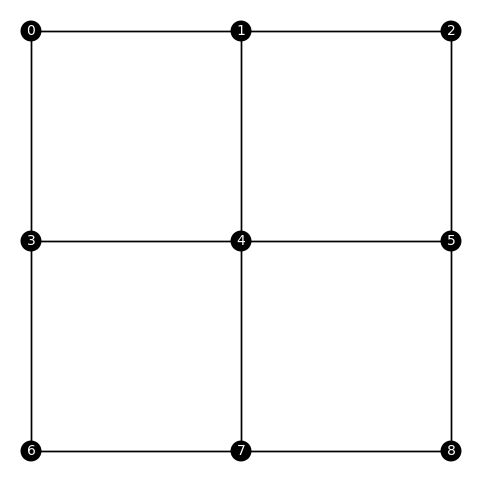

[(0, 3), (1, 4), (2, 5), (3, 6), (4, 7), (5, 8), (6, 0), (7, 1), (8, 2)]


In [193]:
Ny = 20 

ky_list = cp.linspace(cp.pi/Ny, cp.pi, Ny) # k=0 is a special point

lattice = Lattice(3,3, pbc_x=True, pbc_y=True)
print(len(lattice.edges_x))
print(len(lattice.edges_y))
lattice.plot()
print(lattice.edges_y)

In [194]:
t = 1
mu = -1.8* t
Y,X = 25,25

lattice = Lattice(X, Y, pbc_x=True, pbc_y=True)

U0 = 2.0 * t 
U = U0 * cp.ones(lattice.num_sites)
V0 = 2.0 * t 
V = V0 * cp.ones(lattice.num_sites)

H = Hamiltonian(lattice)

In [195]:
U0 = 2 * t 
U = U0 * cp.ones(lattice.num_sites)
V0 = 2.0 * t 
V = V0 * cp.ones(lattice.num_sites)
V0_prime = 0 * t 
V_prime = V0_prime * cp.ones(lattice.num_sites)

In [204]:
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)

for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    H.set_block(i,i, block)

for i, j in lattice.edges_x + lattice.edges_y:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0
    H.set_block(i,j, block)
    H.set_block(j,i, block)

F0 = cp.ones(lattice.num_sites, dtype=cp.complex128) * 0

Fx_plus = 0.1 * cp.ones(len(lattice.edges_x), dtype=cp.complex128)
Fx_min = -0.1 * cp.ones(len(lattice.edges_x), dtype=cp.complex128)
Fy_plus = 0.1j * cp.ones(len(lattice.edges_y), dtype=cp.complex128)
Fy_min = -0.1j * cp.ones(len(lattice.edges_y), dtype=cp.complex128)

# Fx_plus = 0.4 * cp.ones(len(lattice.edges_x), dtype=cp.complex128)
# Fx_min = -0.4 * cp.ones(len(lattice.edges_x), dtype=cp.complex128)
# Fy_plus = 0.4 * cp.ones(len(lattice.edges_y), dtype=cp.complex128)
# Fy_min = -0.4 * cp.ones(len(lattice.edges_y), dtype=cp.complex128)

Fx_uu_plus = H.Fx_uu_plus
Fx_uu_min = H.Fx_uu_min
Fy_uu_plus = H.Fy_uu_plus
Fy_uu_min = H.Fy_uu_min

Fx_dd_plus = H.Fx_dd_plus
Fx_dd_min = H.Fx_dd_min
Fy_dd_plus = H.Fy_dd_plus
Fy_dd_min = H.Fy_dd_min

block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(H.lattice.num_sites):
    block = H.get_block(i, i)
    block[:2, 2:] = -1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])
    block[:2, 2:] += -1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i])
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i])
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i])
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i])

    block[2:, :2] = (-1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])).conj().T
    block[2:, :2] += (-1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])).conj().T
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i]).conj().T
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i]).conj().T
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i]).conj().T
    block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i]).conj().T

    block[:2, :2] = - 2 * t * s0
    block[2:, 2:] = 2 * t * s0

    H.set_block(i, i, block)

for b,(i,j) in enumerate(H.lattice.edges_x):
    
    block = H.get_block(i, j)
    
    block[0, 3] = V[i] * Fx_plus[b]
    block[1, 2] = - V[i] * Fx_min[b]
    block[2, 1] = - V[i] * Fx_plus[b]
    block[3, 0] = V[i] * Fx_min[b]

    block[0, 2] = V_prime[i] * Fx_uu_plus[b]
    block[1, 3] = V_prime[i] * Fx_dd_plus[b]
    block[2, 0] = (V_prime[i] * Fx_uu_min[b]).conj()
    block[3, 1] = (V_prime[i] * Fx_dd_min[b]).conj()

    H.set_block(i, j, block)

    block = H.get_block(j, i)

    block[0, 3] = V[j] * Fx_min[b]
    block[1, 2] = - V[j] * Fx_plus[b]
    block[2, 1] = - V[j] * Fx_min[b]
    block[3, 0] = V[j] * Fx_plus[b]

    block[0, 2] = V_prime[j] * Fx_uu_min[b]
    block[1, 3] = V_prime[j] * Fx_dd_min[b]
    block[2, 0] = (V_prime[j] * Fx_uu_plus[b]).conj()
    block[3, 1] = (V_prime[j] * Fx_dd_plus[b]).conj()

    H.set_block(j, i, block)

for ky in ky_list:
    # Update the Hamiltonian blocks with the new order parameters for this ky
    for i in range(H.lattice.num_sites):
        block = H.get_block(i, i)
        
        block[:2, :2] += -(2 * t * cp.cos(ky)) * s0
        block[2:, 2:] += (2 * t * cp.cos(ky)) * s0
        
        block[:2, 2:] += -1j * s2 * (V[i] * Fy_plus[i] * cp.exp(-1j * ky))
        block[:2, 2:] += -1j * s2 * (V[i] * Fy_min[i] * cp.exp(1j * ky))
        block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i] * cp.exp(-1j * ky))
        block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i] * cp.exp(1j * ky))
        block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i] * cp.exp(-1j * ky))
        block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i] * cp.exp(1j * ky))

        block[2:, :2] += -1j * s2 * (V[i] * Fy_plus[i] * cp.exp(-1j * ky)).conj().T
        block[2:, :2] += -1j * s2 * (V[i] * Fy_min[i] * cp.exp(1j * ky)).conj().T
        block[2:, :2] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i] * cp.exp(-1j * ky)).conj().T
        block[2:, :2] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i] * cp.exp(1j * ky)).conj().T
        block[2:, :2] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i] * cp.exp(-1j * ky)).conj().T
        block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i] * cp.exp(1j * ky)).conj().T

        H.set_block(i, i, block)

In [206]:
print(cp.allclose(H.matrix, H.matrix.conj().T, rtol=1e-6, atol=1e-6))

False


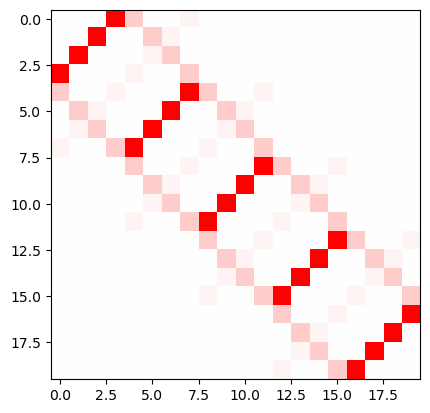

In [207]:
plt.imshow(cp.asnumpy(cp.abs(H.matrix))[:20,:20], cmap='bwr', vmin=-cp.max(cp.abs(H.matrix)), vmax=cp.max(cp.abs(H.matrix)))

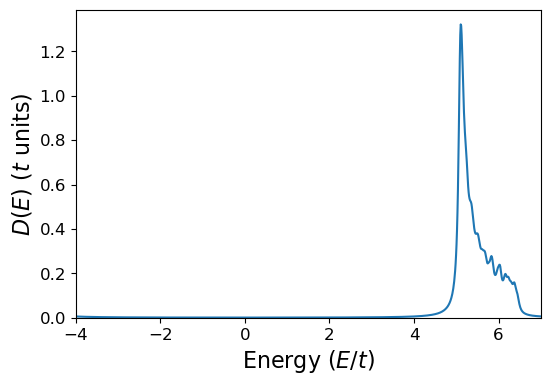

In [208]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.05, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
def self_consistency(H, U=None, V=None, V_prime=None, temperature=0,
                     abs_tol=1e-6, rel_tol=1e-3, max_iter=100):
    
    if U is None:
        U = cp.zeros(H.lattice.num_sites)
    if V is None:
        V = cp.zeros(H.lattice.num_sites)
    if V_prime is None:
        V_prime = cp.zeros(H.lattice.num_sites)

    Nx = H.lattice.X
    Ny = H.lattice.Y
    ky_list = cp.linspace(cp.pi/Ny, cp.pi, Ny)

    F0 = H.F0

    Fx_plus = H.Fx_plus
    Fx_min = H.Fx_min
    Fy_plus = H.Fy_plus
    Fy_min = H.Fy_min
    
    Fx_uu_plus = H.Fx_uu_plus
    Fx_uu_min = H.Fx_uu_min
    Fy_uu_plus = H.Fy_uu_plus
    Fy_uu_min = H.Fy_uu_min
    
    Fx_dd_plus = H.Fx_dd_plus
    Fx_dd_min = H.Fx_dd_min
    Fy_dd_plus = H.Fy_dd_plus
    Fy_dd_min = H.Fy_dd_min

    for iteration in range(max_iter):
        for i in range(H.lattice.num_sites):
            block = H.get_block(i, i)
            block[:2, 2:] = -1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])
            block[:2, 2:] += -1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i])
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i])
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i])
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i])

            block[2:, :2] = (-1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])).conj().T
            block[2:, :2] += (-1j * s2 * (U[i] * F0[i] + V[i] * Fy_min[i] + V[i] * Fy_plus[i])).conj().T
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i]).conj().T
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i]).conj().T
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i]).conj().T
            block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i]).conj().T

            block[:2, :2] = - 2 * t * s0
            block[2:, 2:] = 2 * t * s0
      
            H.set_block(i, i, block)

        for b,(i,j) in enumerate(H.lattice.edges_x):
            block = H.get_block(i, j)
            
            block[0, 3] = V[i] * Fx_plus[b]
            block[1, 2] = - V[i] * Fx_min[b]
            block[2, 1] = - V[i] * Fx_plus[b]
            block[3, 0] = V[i] * Fx_min[b]

            block[0, 2] = V_prime[i] * Fx_uu_plus[b]
            block[1, 3] = V_prime[i] * Fx_dd_plus[b]
            block[2, 0] = (V_prime[i] * Fx_uu_min[b]).conj()
            block[3, 1] = (V_prime[i] * Fx_dd_min[b]).conj()

            H.set_block(i, j, block)

            block = H.get_block(j, i)

            block[0, 3] = V[j] * Fx_min[b]
            block[1, 2] = - V[j] * Fx_plus[b]
            block[2, 1] = - V[j] * Fx_min[b]
            block[3, 0] = V[j] * Fx_plus[b]

            block[0, 2] = V_prime[j] * Fx_uu_min[b]
            block[1, 3] = V_prime[j] * Fx_dd_min[b]
            block[2, 0] = (V_prime[j] * Fx_uu_plus[b]).conj()
            block[3, 1] = (V_prime[j] * Fx_dd_plus[b]).conj()

            H.set_block(j, i, block)

        eigval, eigvec = H.diagonalize(drop_matrix=False)
        eigvec = eigvec[:, eigval >= 0]
        eigval = eigval[eigval >= 0]
        eigvec = eigvec.T.reshape((eigval.size, -1, 4))

        f = fermi_dirac(eigval, temperature)          # (Neig,)
        u_up = eigvec[:, :, 0]  # u             # (Neig, Nsites)
        u_dn = eigvec[:, :, 1]  # v
        v_up = eigvec[:, :, 2]  # w
        v_dn = eigvec[:, :, 3]  # x

        Fx0_updn1 = u_up[:-1, :] * cp.conj(v_dn[1:, :])  * (1 - f[:-1, :])
        Fx0_dnup2 = u_dn[1:,  :] * cp.conj(v_up[:-1, :]) * f[1:, :]
        Fx0_updn2 = u_up[1:,  :] * cp.conj(v_dn[:-1, :]) * (1 - f[1:,  :])
        Fx0_dnup1 = u_dn[:-1, :] * cp.conj(v_up[1:, :])  * f[:-1,  :]

        Fy0_updn  = u_up * cp.conj(u_dn) * (1 - f)
        Fy0_dnup  = v_up * cp.conj(v_dn) * f

        Fx_plus_new = cp.sum(Fx0_updn1 + Fx0_dnup2, axis=1) / Ny
        Fx_min_new = cp.sum(Fx0_updn2 + Fx0_dnup1, axis=1) / Ny
        K_y0 = cp.sum(Fy0_updn + Fy0_dnup, axis=1) / Ny
        Fy_plus_new = K_y0
        Fy_min_new = K_y0

        Fy_dd_plus_new = cp.zeros_like(Fy_dd_plus)
        Fy_dd_min_new = cp.zeros_like(Fy_dd_min)
        Fy_uu_plus_new = cp.zeros_like(Fy_uu_plus)
        Fy_uu_min_new = cp.zeros_like(Fy_uu_min)

        Fx_dd_plus_new = cp.zeros_like(Fy_dd_plus)
        Fx_dd_min_new = cp.zeros_like(Fy_dd_min)
        Fx_uu_plus_new = cp.zeros_like(Fy_uu_plus)
        Fx_uu_min_new = cp.zeros_like(Fy_uu_min)
        
        for ky in ky_list:
            # Update the Hamiltonian blocks with the new order parameters for this ky
            for i in range(H.lattice.num_sites):
                block = H.get_block(i, i)
                
                block[:2, :2] = -(mu + 2 * t * cp.cos(ky)) * s0
                block[2:, 2:] = (mu + 2 * t * cp.cos(ky)) * s0
                
                block[:2, 2:] = -1j * s2 * (U[i] * F0[i])
                block[:2, 2:] += -1j * s2 * (V[i] * Fy_plus[i] * cp.exp(-1j * ky))
                block[:2, 2:] += -1j * s2 * (V[i] * Fy_min[i] * cp.exp(1j * ky))
                block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i] * cp.exp(-1j * ky))
                block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i] * cp.exp(1j * ky))
                block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i] * cp.exp(-1j * ky))
                block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i] * cp.exp(1j * ky))

                block[2:, :2] = -1j * s2 * (U[i] * F0[i]).conj().T
                block[2:, :2] += -1j * s2 * (V[i] * Fy_plus[i] * cp.exp(-1j * ky)).conj().T
                block[2:, :2] += -1j * s2 * (V[i] * Fy_min[i] * cp.exp(1j * ky)).conj().T
                block[2:, :2] += -1j * s2 * (V_prime[i]/2 * Fy_dd_plus[i] * cp.exp(-1j * ky)).conj().T
                block[2:, :2] += -1j * s2 * (V_prime[i]/2 * Fy_dd_min[i] * cp.exp(1j * ky)).conj().T
                block[2:, :2] += -1j * s2 * (V_prime[i]/2 * Fy_uu_plus[i] * cp.exp(-1j * ky)).conj().T
                block[:2, 2:] += -1j * s2 * (V_prime[i]/2 * Fy_uu_min[i] * cp.exp(1j * ky)).conj().T
        
                H.set_block(i, i, block)

            f = fermi_dirac(eigval, temperature)          # (Neig,)
            u_up = eigvec[:, :, 0]  # u             # (Neig, Nsites)
            u_dn = eigvec[:, :, 1]  # v
            v_up = eigvec[:, :, 2]  # w
            v_dn = eigvec[:, :, 3]  # x

            Fx_updn1 = u_up[:-1, :] * cp.conj(v_dn[1:, :])  * (1 - f[:-1, :])
            Fx_dnup2 = u_dn[1:,  :] * cp.conj(v_up[:-1, :]) * f[1:, :]
            Fx_updn2 = u_up[1:,  :] * cp.conj(v_dn[:-1, :]) * (1 - f[1:,  :])
            Fx_dnup1 = u_dn[:-1, :] * cp.conj(v_up[1:, :])  * f[:-1,  :]


            Fy_updn  = u_up * cp.conj(u_dn) * (1 - f)
            Fy_dnup  = v_up * cp.conj(v_dn) * f

            Fx_plus_new += cp.sum(Fx_updn1 + Fx_dnup2, axis=1) / Ny
            Fx_min_new += cp.sum(Fx_updn2 + Fx_dnup1, axis=1) / Ny
            Fy_plus_new += cp.sum(Fy_updn + Fy_dnup, axis=1) / Ny
            Fy_min_new += cp.sum(Fy_updn + Fy_dnup, axis=1) / Ny